# 02 — Feature Engineering

The dataset ships 561 ready-made features. It would be easy to use them without
ever knowing what they are. This notebook builds a smaller feature set from the
raw signals by hand, so the features stop being a black box, and then checks
whether that hand-built set is good enough to compete with the official one.

The features live in `src/features.py`; this notebook imports and demonstrates
them. Two families per channel — time domain (mean, std, energy, mean-crossing
rate, skew, kurtosis, …) and frequency domain (dominant frequency, spectral
entropy, spectral centroid, …) — plus cross-axis correlations.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_features, load_raw_signals, ACTIVITY_LABELS
from src.features import extract_window_features, extract_features_batch

sns.set_theme(style="whitegrid", context="notebook")

X_raw_tr, y_tr, subj_tr = load_raw_signals("train")
X_raw_te, y_te, subj_te = load_raw_signals("test")
print(f"Raw train: {X_raw_tr.shape}   Raw test: {X_raw_te.shape}")

Raw train: (7352, 128, 9)   Raw test: (2947, 128, 9)


## 1. Features from a single window

Every window becomes a fixed-length vector of numbers. Here is what the extractor
produces for one window, showing a few of the time- and frequency-domain values
for the first accelerometer axis.

In [2]:
window = X_raw_tr[0]                 # (128, 9)
feats = extract_window_features(window)
print(f"Total features per window: {len(feats)}\n")

# Show a readable slice: the body_acc_x features.
print("body_acc_x features:")
for name, val in feats.items():
    if name.startswith("body_acc_x_"):
        print(f"  {name:28s} {val: .4f}")

Total features per window: 162

body_acc_x features:
  body_acc_x_mean               0.0023
  body_acc_x_std                0.0029
  body_acc_x_min               -0.0043
  body_acc_x_max                0.0108
  body_acc_x_median             0.0020
  body_acc_x_range              0.0151
  body_acc_x_energy             0.0000
  body_acc_x_rms                0.0037
  body_acc_x_iqr                0.0048
  body_acc_x_mad                0.0025
  body_acc_x_mcr                0.1406
  body_acc_x_skew               0.4811
  body_acc_x_kurtosis          -0.3958
  body_acc_x_dom_freq           0.3906
  body_acc_x_spec_energy        0.0006
  body_acc_x_spec_entropy       5.4153
  body_acc_x_spec_centroid      8.0834


## 2. Extract features for the whole dataset

Extraction runs a Python loop over every window, so it takes a minute or two the
first time. The result is cached to disk (inside the gitignored `data/` folder),
so re-running the notebook is instant afterwards.

In [3]:
cache = Path.cwd().parent / "data" / "custom_features.npz"

if cache.exists():
    print("Loading cached features...")
    d = np.load(cache, allow_pickle=True)
    Xc_tr, Xc_te = d["Xc_tr"], d["Xc_te"]
    feat_names = list(d["feat_names"])
else:
    print("Extracting features (first run, ~1-2 min)...")
    Xc_tr, feat_names = extract_features_batch(X_raw_tr)
    Xc_te, _ = extract_features_batch(X_raw_te)
    np.savez(cache, Xc_tr=Xc_tr, Xc_te=Xc_te,
             feat_names=np.array(feat_names, dtype=object))

print(f"Custom features — train: {Xc_tr.shape}, test: {Xc_te.shape}")
print(f"NaNs present: {np.isnan(Xc_tr).any() or np.isnan(Xc_te).any()}")

Loading cached features...
Custom features — train: (7352, 162), test: (2947, 162)
NaNs present: False


## 3. Custom set vs the official 561

Our hand-built set is far smaller. The official set includes many extra
band-energy and angle features we deliberately left out to keep things readable.
The real question is not how many features we have, but whether ours carry enough
information to classify well.

In [4]:
Xo_tr, _, _ = load_features("train")
Xo_te, _, _ = load_features("test")

print(f"Custom feature set:   {Xc_tr.shape[1]} features")
print(f"Official feature set: {Xo_tr.shape[1]} features")

Custom feature set:   162 features
Official feature set: 561 features


## 4. Do our features actually work?

A quick test: train the same model (a Random Forest) on each feature set and
compare on the **subject-independent test set**. This is a preview of Step 3, run
here only to sanity-check the features. If our 162 features land close to the
official 561, the hand-built set is doing its job.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

def quick_eval(X_tr, X_te, label):
    clf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1 = f1_score(y_te, pred, average="macro")
    print(f"{label:22s} accuracy={acc:.3f}  macro-F1={f1:.3f}")
    return clf

print("Random Forest, evaluated on unseen subjects:\n")
clf_custom = quick_eval(Xc_tr, Xc_te, "Custom (162 feats)")
_          = quick_eval(Xo_tr, Xo_te, "Official (561 feats)")

Random Forest, evaluated on unseen subjects:



Custom (162 feats)     accuracy=0.922  macro-F1=0.921


Official (561 feats)   accuracy=0.928  macro-F1=0.926


The two land close together. With roughly a third as many features, all derived
from raw signal by hand, the custom set is competitive with the official one.
That is the point of the exercise: the 561 features are not magic, they are just
more of the same kinds of statistics computed here.

## 5. Which features carry the signal?

The Random Forest exposes how much each feature contributed. The top features
tell us what the model actually keys on to tell activities apart.

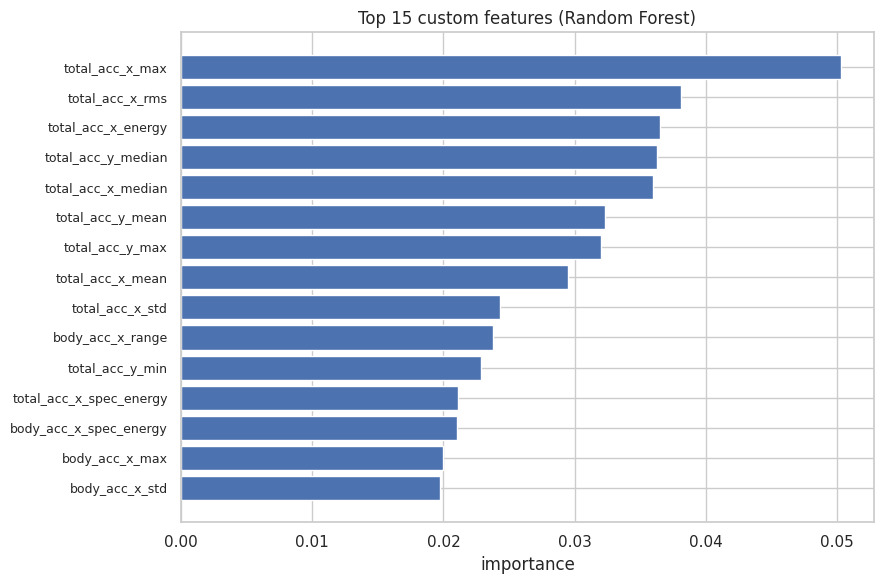

In [6]:
importances = clf_custom.feature_importances_
order = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(order)), importances[order][::-1], color="#4c72b0")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([feat_names[i] for i in order][::-1], fontsize=9)
ax.set_xlabel("importance")
ax.set_title("Top 15 custom features (Random Forest)")
plt.tight_layout()
plt.show()

The top of the list is dominated by **total-acceleration** statistics, and this
splits neatly into the two things a model needs:

- **Movement magnitude** — `total_acc` max, rms and energy are large during
  walking and small when still, so they separate the moving activities from the
  static ones.
- **Orientation** — `total_acc` mean and median encode the direction of gravity,
  which is the subtle cue that separates the static postures (sitting, standing,
  laying) from each other.

Body-acceleration spread (`body_acc` std, range) and spectral-energy features
also contribute. This lines up directly with the EDA: magnitude separates moving
from still, and orientation is what little there is to tell the still activities
apart.

## Takeaways

- Each 2.56 s window is reduced to a fixed vector of interpretable features.
- A hand-built set of 162 features is competitive with the official 561 on the
  subject-independent test set, so the official features are understandable, not
  magic.
- The most informative features split into movement magnitude (total-acceleration
  max, rms, energy) and orientation (total-acceleration mean, median) — exactly
  the two cues the EDA pointed to.
- Step 3 uses the official 561 features for the main model comparison, now with
  a clear understanding of what those features represent.